# Training Deteksi PrivAI — YOLO26n

Notebook ini melatih satu detector lokal untuk 9 kelas: `ktp`, `sim`, `paspor`, `teks_sensitif`, `wajah`, `plat_nomor`, `kk`, `kartu_atm`, dan `resi`.

Konfigurasi utama:

- model `yolo26n.pt`: varian nano yang cepat dan portable untuk edge/CPU;
- split dataset final `train`, `val`, dan `test` dibuat otomatis;
- `last.pt` diperbarui setiap epoch dan checkpoint bernomor disimpan setiap 5 epoch;
- training dapat dilanjutkan otomatis dari `last.pt` setelah crash;
- early stopping setelah 25 epoch tanpa peningkatan validation fitness;
- `best.pt`, `last.pt`, histori CSV, grafik, manifest dataset, serta hasil val/test disimpan;
- horizontal/vertical flip dinonaktifkan agar teks, nomor identitas, nomor kartu, barcode, dan wajah tidak menjadi mirror.

## Posisi model dalam sistem Spectre

Model ini adalah **Visual Firewall** lokal dan offline. Satu detector melakukan lokalisasi dokumen serta region sensitif tanpa OCR/NER. Bounding box hasil detector diteruskan ke OpenCV untuk redaksi tingkat piksel. Media yang sudah disensor menjadi lapisan publik, sedangkan media asli masuk ke jalur vault terenkripsi AES-256-GCM.

Karena false negative dapat membocorkan data sensitif, pemilihan model dan evaluasi di notebook ini memprioritaskan **recall**, lalu mAP dan precision. Test split hanya dipakai untuk evaluasi akhir, bukan untuk pemilihan checkpoint.

## 1. Instalasi

Jalankan sekali, lalu restart kernel bila versi Ultralytics berubah. PyTorch CUDA sebaiknya dipasang terpisah sesuai versi driver/GPU dari situs resmi PyTorch.

In [1]:
%pip install -U "ultralytics==8.4.96" "pandas>=2.0" "matplotlib>=3.7"

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import hashlib
import json
import os
import random
import re
import shutil
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import ultralytics
from IPython.display import display
from packaging.version import Version
from ultralytics import YOLO

MIN_ULTRALYTICS = Version("8.4.96")
if Version(ultralytics.__version__) < MIN_ULTRALYTICS:
    raise RuntimeError(
        f"Ultralytics {ultralytics.__version__} masih terlalu lama. "
        "Jalankan sel instalasi lalu restart kernel."
    )

USE_CUDA = torch.cuda.is_available()
USE_MPS = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
DEVICE = 0 if USE_CUDA else ("mps" if USE_MPS else "cpu")

print("Ultralytics :", ultralytics.__version__)
print("PyTorch     :", torch.__version__)
print("Device      :", DEVICE)
if USE_CUDA:
    print("GPU         :", torch.cuda.get_device_name(0))
else:
    print("PERINGATAN  : training penuh di CPU akan jauh lebih lambat daripada GPU.")

WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\User\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics : 8.4.96
PyTorch     : 2.12.1+cu130
Device      : 0
GPU         : NVIDIA GeForce RTX 3050 Laptop GPU


## 2. Konfigurasi eksperimen

`MAX_EPOCHS=200` adalah batas atas, bukan target wajib. Training berhenti lebih awal bila validation fitness tidak membaik selama `PATIENCE=25` epoch. `SAVE_PERIOD=5` memberi checkpoint historis yang cukup rapat tanpa memenuhi disk; `last.pt` tetap diperbarui setiap epoch.

In [3]:
PROJECT_ROOT = Path.cwd().resolve()
DATASETS_ROOT = PROJECT_ROOT / "datasets"
REAL_DATA_ROOT = PROJECT_ROOT / "data_asli"
AUGMENTED_DATA_ROOT = PROJECT_ROOT / "data_augmentasi"
COMBINED_ROOT = DATASETS_ROOT / "privai_combined"
DATA_YAML = COMBINED_ROOT / "data.yaml"
RUNS_ROOT = PROJECT_ROOT / "runs" / "detect"
MODELS_ROOT = PROJECT_ROOT / "models"

if not DATASETS_ROOT.exists():
    raise FileNotFoundError(
        f"Folder dataset tidak ditemukan di {DATASETS_ROOT}. "
        "Buka notebook dengan working directory folder proyek Data."
    )

CLASS_NAMES = {
    0: "ktp",
    1: "sim",
    2: "paspor",
    3: "teks_sensitif",
    4: "wajah",
    5: "plat_nomor",
    6: "kk",
    7: "kartu_atm",
    8: "resi",
}

SYNTHETIC_SOURCE_NAMES = (
    "ktp_synth",
    "sim_synth",
    "paspor_synth",
    "kk_synth",
    "atm_synth",
    "resi_synth",
    "plat_synth",
)
REAL_SOURCE_NAMES = ("ktp", "sim", "paspor", "kk", "atm", "resi", "plat", "widerface")

MODEL_NAME = "yolo26n.pt"
RUN_NAME = "privai_yolo26n"
IMAGE_SIZE = 640
MAX_EPOCHS = 200
PATIENCE = 25
SAVE_PERIOD = 5
SEED = 42
REBUILD_COMBINED_DATASET = True
RESUME_IF_AVAILABLE = True

# Auto-batch 70% VRAM di CUDA; nilai kecil yang aman saat CPU/MPS.
TRAIN_BATCH = 0.70 if USE_CUDA else 4
EVAL_BATCH = 16 if USE_CUDA else 4
WORKERS = 0 if os.name == "nt" else min(8, os.cpu_count() or 2)

random.seed(SEED)
print("Project root:", PROJECT_ROOT)
print("Model       :", MODEL_NAME)
print("Batch train :", TRAIN_BATCH)
print("Workers     :", WORKERS)

Project root: C:\Users\User\Downloads\Data
Model       : yolo26n.pt
Batch train : 0.7
Workers     : 0


## 3. Bangun dataset gabungan train/val/test

Strategi split dilakukan berdasarkan parent gambar, bukan kata `asli` pada nama file:

- data asli dan sintetis unik: 70% train, 15% validation, 15% test;
- seluruh turunan augmentasi mengikuti parent aslinya dan hanya disalin jika parent masuk train.

File `nama_aug_000` dikelompokkan dengan parent `nama`, sehingga versi asli dan turunannya tidak mungkin bocor ke split berbeda. Validation dan test tetap berisi gambar independen, bukan hasil augmentasi.

In [4]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def discover_sources() -> list[dict]:
    sources = []
    for name in SYNTHETIC_SOURCE_NAMES:
        root = DATASETS_ROOT / name
        if root.exists():
            sources.append({"id": f"synthetic__{name}", "name": name, "kind": "synthetic", "roots": [root]})
    for name in REAL_SOURCE_NAMES:
        roots = [root for root in (REAL_DATA_ROOT / name, AUGMENTED_DATA_ROOT / name) if root.exists()]
        if roots:
            sources.append({"id": f"real__{name}", "name": name, "kind": "real", "roots": roots})
    return sources


def label_for_image(image_path: Path, source_root: Path) -> Path:
    rel = image_path.relative_to(source_root)
    if rel.parts and rel.parts[0].lower() == "images":
        return source_root / "labels" / Path(*rel.parts[1:]).with_suffix(".txt")
    return image_path.with_suffix(".txt")


def collect_pairs(source_roots: list[Path]) -> list[tuple[Path, Path]]:
    pairs = []
    for source_root in source_roots:
        for image_path in sorted(source_root.rglob("*")):
            if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            label_path = label_for_image(image_path, source_root)
            if label_path.exists():
                pairs.append((image_path, label_path))
            else:
                print(f"Lewati tanpa label: {image_path}")
    return pairs


def normalized_group_key(stem: str) -> str:
    key = stem.lower()
    # Menyatukan pola umum: nama_original, nama_aug_01, nama_variant-2, dst.
    key = re.sub(r"(?:[_-](?:original|orig|aug(?:mented)?|variant|copy))[_-]?\d*$", "", key)
    return key


def allocate_group_counts(total: int, ratios: tuple[float, float, float]) -> tuple[int, int, int]:
    if total <= 0:
        return 0, 0, 0
    if total == 1:
        return 1, 0, 0
    if total == 2:
        return 1, 1, 0

    train_count = max(1, round(total * ratios[0]))
    val_count = max(1, round(total * ratios[1]))
    if train_count + val_count >= total:
        train_count = total - val_count - 1
    test_count = total - train_count - val_count
    return train_count, val_count, test_count


def split_source_pairs(source: dict, pairs: list[tuple[Path, Path]]) -> dict[str, list[tuple[Path, Path]]]:
    groups = defaultdict(list)
    for pair in pairs:
        groups[normalized_group_key(pair[0].stem)].append(pair)

    group_keys = list(groups)
    stable_seed = int(hashlib.sha1(source["id"].encode("utf-8")).hexdigest()[:8], 16)
    random.Random(SEED + stable_seed).shuffle(group_keys)

    ratios = (0.70, 0.15, 0.15)
    n_train, n_val, _ = allocate_group_counts(len(group_keys), ratios)
    key_splits = {
        "train": group_keys[:n_train],
        "val": group_keys[n_train:n_train + n_val],
        "test": group_keys[n_train + n_val:],
    }
    result = {split: [pair for key in keys for pair in groups[key]] for split, keys in key_splits.items()}
    for split in ("val", "test"):
        result[split] = [pair for pair in result[split] if AUGMENTED_DATA_ROOT not in pair[0].parents]
    return result


def read_and_validate_yolo_label(label_path: Path) -> tuple[int, Counter]:
    box_count = 0
    class_counts = Counter()
    for line_no, raw_line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        line = raw_line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"Format label bukan YOLO 5 kolom: {label_path}:{line_no}")
        class_value = float(parts[0])
        class_id = int(class_value)
        if class_value != class_id or class_id not in CLASS_NAMES:
            raise ValueError(f"Class ID tidak valid: {label_path}:{line_no} -> {parts[0]}")
        x, y, width, height = map(float, parts[1:])
        if not all(-1e-6 <= value <= 1.000001 for value in (x, y, width, height)):
            raise ValueError(f"Koordinat di luar 0..1: {label_path}:{line_no}")
        if width <= 0 or height <= 0:
            raise ValueError(f"Bounding box kosong: {label_path}:{line_no}")
        box_count += 1
        class_counts[class_id] += 1
    return box_count, class_counts


sources = discover_sources()
if not sources:
    raise RuntimeError("Tidak ada sumber dataset yang ditemukan.")

combined_resolved = COMBINED_ROOT.resolve()
if combined_resolved.parent != DATASETS_ROOT.resolve() or combined_resolved.name != "privai_combined":
    raise RuntimeError(f"Lokasi combined dataset tidak aman: {combined_resolved}")
if REBUILD_COMBINED_DATASET and COMBINED_ROOT.exists():
    shutil.rmtree(COMBINED_ROOT)

for split in ("train", "val", "test"):
    (COMBINED_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (COMBINED_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

manifest_rows = []
global_class_counts = Counter()
target_counter = 0

for source in sources:
    pairs = collect_pairs(source["roots"])
    if not pairs:
        print(f"Sumber kosong, dilewati: {source['roots']}")
        continue

    for split, split_pairs in split_source_pairs(source, pairs).items():
        for image_path, label_path in split_pairs:
            box_count, class_counts = read_and_validate_yolo_label(label_path)
            safe_stem = re.sub(r"[^a-zA-Z0-9_-]+", "_", image_path.stem)
            target_stem = f"{source['id']}__{target_counter:06d}__{safe_stem}"
            target_counter += 1

            target_image = COMBINED_ROOT / "images" / split / f"{target_stem}{image_path.suffix.lower()}"
            target_label = COMBINED_ROOT / "labels" / split / f"{target_stem}.txt"
            shutil.copy2(image_path, target_image)
            shutil.copy2(label_path, target_label)

            global_class_counts.update(class_counts)
            manifest_rows.append({
                "split": split,
                "source": source["name"],
                "source_kind": "augmented" if AUGMENTED_DATA_ROOT in image_path.parents else source["kind"],
                "original_image": str(image_path),
                "image": str(target_image.relative_to(COMBINED_ROOT)),
                "label": str(target_label.relative_to(COMBINED_ROOT)),
                "box_count": box_count,
                "class_counts": json.dumps(dict(sorted(class_counts.items()))),
            })

manifest = pd.DataFrame(manifest_rows)
if manifest.empty:
    raise RuntimeError("Tidak ada pasangan gambar/label yang berhasil digabungkan.")
if set(manifest["split"]) != {"train", "val", "test"}:
    raise RuntimeError(f"Split belum lengkap: {sorted(manifest['split'].unique())}")

manifest.to_csv(COMBINED_ROOT / "dataset_manifest.csv", index=False)
source_summary = (
    manifest.groupby(["split", "source_kind", "source"], as_index=False)
    .agg(images=("image", "count"), boxes=("box_count", "sum"))
)
source_summary.to_csv(COMBINED_ROOT / "dataset_summary.csv", index=False)

class_summary = pd.DataFrame([
    {"class_id": class_id, "class_name": class_name, "instances": global_class_counts[class_id]}
    for class_id, class_name in CLASS_NAMES.items()
])
class_summary.to_csv(COMBINED_ROOT / "class_distribution.csv", index=False)

yaml_lines = [
    "# PrivAI unified dataset",
    "# PENTING: training wajib memakai fliplr=0.0 dan flipud=0.0; jangan mirror teks/dokumen.",
    f"path: {json.dumps(COMBINED_ROOT.as_posix())}",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "",
    f"nc: {len(CLASS_NAMES)}",
    "names:",
]
yaml_lines.extend(f"  {class_id}: {class_name}" for class_id, class_name in CLASS_NAMES.items())
DATA_YAML.write_text("\n".join(yaml_lines) + "\n", encoding="utf-8")

build_info = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "seed": SEED,
    "base_split": [0.70, 0.15, 0.15],
    "augmented_split": [1.0, 0.0, 0.0],
    "images": int(len(manifest)),
    "boxes": int(manifest["box_count"].sum()),
    "sources": [source["id"] for source in sources],
}
(COMBINED_ROOT / "dataset_build.json").write_text(
    json.dumps(build_info, indent=2), encoding="utf-8"
)

missing_classes = [CLASS_NAMES[class_id] for class_id in CLASS_NAMES if global_class_counts[class_id] == 0]
if missing_classes:
    print("PERINGATAN — belum ada instance untuk class:", ", ".join(missing_classes))
    print("Generate/tambahkan datanya sebelum training produksi agar seluruh 9 class dapat dipelajari.")

print(f"Dataset gabungan: {len(manifest)} gambar, {manifest['box_count'].sum()} bounding box")
print("YAML:", DATA_YAML)
display(source_summary)

Dataset gabungan: 8093 gambar, 137143 bounding box
YAML: C:\Users\User\Downloads\Data\datasets\privai_combined\data.yaml


,split,source_kind,source,images,boxes
0,test,real,atm,1,4
1,test,real,ktp,11,55
2,test,real,paspor,3,15
3,test,real,plat,15,50
4,test,real,sim,2,9
5,test,real,widerface,75,217
6,test,synthetic,atm_synth,150,711
7,test,synthetic,kk_synth,150,11132
8,test,synthetic,ktp_synth,120,2158
9,test,synthetic,paspor_synth,135,1832


## 4. Audit distribusi sebelum training

Sel ini menyimpan tabel dan grafik distribusi agar komposisi eksperimen dapat diaudit serta divisualisasikan kembali.

,images,boxes
split,,
train,5900,97069
val,1096,19865
test,1097,20209


,class_id,class_name,instances
0,0,ktp,1213
1,1,sim,1067
2,2,paspor,1097
3,3,teks_sensitif,122110
4,4,wajah,6366
5,5,plat_nomor,1601
6,6,kk,1026
7,7,kartu_atm,1529
8,8,resi,1134


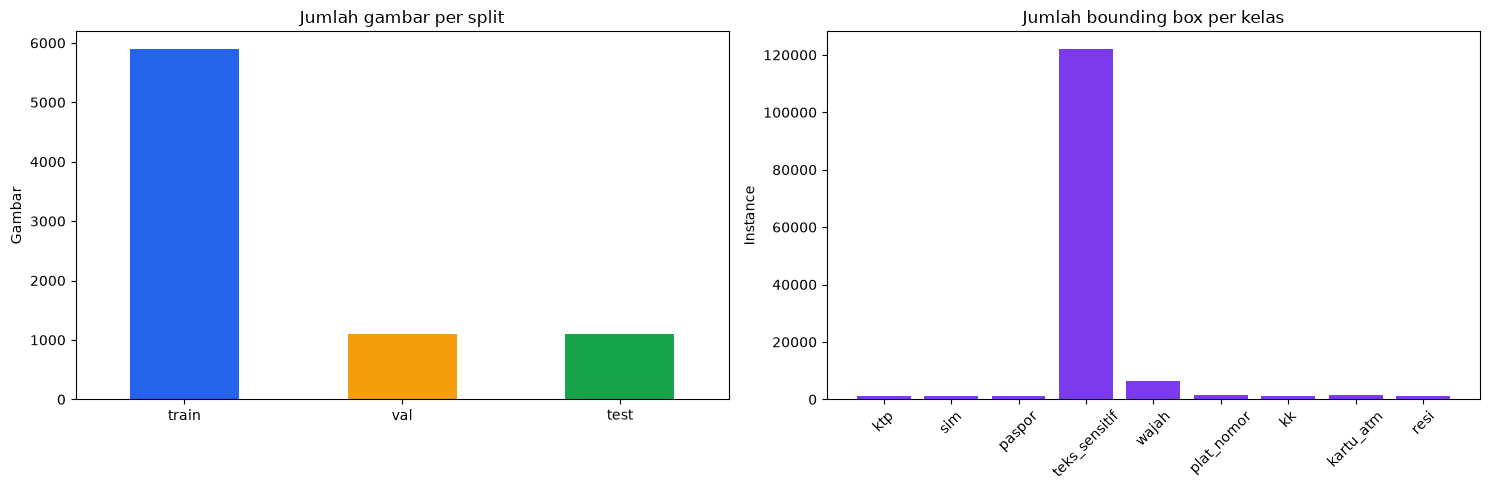

Grafik disimpan: C:\Users\User\Downloads\Data\datasets\privai_combined\dataset_distribution.png


In [5]:
split_summary = (
    manifest.groupby("split", as_index=False)
    .agg(images=("image", "count"), boxes=("box_count", "sum"))
    .set_index("split")
    .reindex(["train", "val", "test"])
)
display(split_summary)
display(class_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
split_summary["images"].plot(kind="bar", ax=axes[0], color=["#2563eb", "#f59e0b", "#16a34a"])
axes[0].set_title("Jumlah gambar per split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Gambar")
axes[0].tick_params(axis="x", rotation=0)

axes[1].bar(class_summary["class_name"], class_summary["instances"], color="#7c3aed")
axes[1].set_title("Jumlah bounding box per kelas")
axes[1].set_ylabel("Instance")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
distribution_plot = COMBINED_ROOT / "dataset_distribution.png"
fig.savefig(distribution_plot, dpi=160, bbox_inches="tight")
plt.show()
print("Grafik disimpan:", distribution_plot)

## 5. Training atau resume

Saat run baru, Ultralytics menyimpan `best.pt` dan memperbarui `last.pt` setiap epoch. Selain itu `epoch5.pt`, `epoch10.pt`, dan seterusnya disimpan setiap 5 epoch. Jika kernel/komputer crash, jalankan ulang notebook sampai sel ini; ketika `last.pt` ditemukan, optimizer, scheduler, nomor epoch, dan weight dipulihkan dengan `resume=True`.

Jika ingin memulai eksperimen baru dari nol, ubah `RUN_NAME` atau set `RESUME_IF_AVAILABLE=False`.

In [6]:
RUN_DIR = RUNS_ROOT / RUN_NAME
LAST_WEIGHT = RUN_DIR / "weights" / "last.pt"
BEST_WEIGHT = RUN_DIR / "weights" / "best.pt"

train_args = {
    "data": str(DATA_YAML),
    "epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "imgsz": IMAGE_SIZE,
    "batch": TRAIN_BATCH,
    "device": DEVICE,
    "workers": WORKERS,
    "optimizer": "auto",
    "project": str(RUNS_ROOT),
    "name": RUN_NAME,
    "exist_ok": True,
    "save": True,
    "save_period": SAVE_PERIOD,
    "plots": True,
    "val": True,
    "seed": SEED,
    "deterministic": True,
    "amp": USE_CUDA,
    "cos_lr": True,
    "close_mosaic": 10,
    "max_det": 500,
    # Dokumen tidak boleh dibalik/mirror.
    "fliplr": 0.0,
    "flipud": 0.0,
    # Augmentasi ringan; generator data sudah menyediakan skenario ekstrem.
    "degrees": 12.0,
    "translate": 0.08,
    "scale": 0.30,
    "shear": 2.0,
    "perspective": 0.0005,
    "mosaic": 0.35,
    "mixup": 0.0,
    "copy_paste": 0.0,
    "hsv_h": 0.01,
    "hsv_s": 0.35,
    "hsv_v": 0.25,
}

if RESUME_IF_AVAILABLE and LAST_WEIGHT.exists():
    print("Resume checkpoint:", LAST_WEIGHT)
    model = YOLO(str(LAST_WEIGHT))
    train_results = model.train(resume=True)
else:
    print("Mulai run baru dari:", MODEL_NAME)
    model = YOLO(MODEL_NAME)
    train_results = model.train(**train_args)

actual_run_dir = Path(model.trainer.save_dir).resolve()
BEST_WEIGHT = actual_run_dir / "weights" / "best.pt"
LAST_WEIGHT = actual_run_dir / "weights" / "last.pt"
if not BEST_WEIGHT.exists() or not LAST_WEIGHT.exists():
    raise FileNotFoundError("Training selesai tetapi best.pt/last.pt tidak ditemukan.")

print("Run directory:", actual_run_dir)
print("Best weight  :", BEST_WEIGHT)
print("Latest weight:", LAST_WEIGHT)

Resume checkpoint: C:\Users\User\Downloads\Data\runs\detect\privai_yolo26n\weights\last.pt
Ultralytics 8.4.96  Python-3.13.1 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=5, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\User\Downloads\Data\datasets\privai_combined\data.yaml, degrees=12.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.35, hsv_v=0.25, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=500, mixup=0.0, mode=train, mode

KeyboardInterrupt: 

## 6. Arsipkan best/latest dan histori training

Selain file di folder run, notebook membuat alias stabil di folder `models/` agar aplikasi inference tidak perlu menebak nama run.

In [ ]:
MODELS_ROOT.mkdir(parents=True, exist_ok=True)
STABLE_BEST = MODELS_ROOT / "privai_best.pt"
STABLE_LATEST = MODELS_ROOT / "privai_latest.pt"
shutil.copy2(BEST_WEIGHT, STABLE_BEST)
shutil.copy2(LAST_WEIGHT, STABLE_LATEST)

history_path = actual_run_dir / "results.csv"
if history_path.exists():
    history = pd.read_csv(history_path)
    history.to_csv(MODELS_ROOT / "privai_training_history.csv", index=False)
    display(history.tail(10))
else:
    history = pd.DataFrame()
    print("PERINGATAN: results.csv tidak ditemukan.")

run_manifest = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "base_model": MODEL_NAME,
    "ultralytics": ultralytics.__version__,
    "torch": torch.__version__,
    "device": str(DEVICE),
    "data_yaml": str(DATA_YAML),
    "run_dir": str(actual_run_dir),
    "best_weight": str(STABLE_BEST),
    "latest_weight": str(STABLE_LATEST),
    "checkpoint_period_epochs": SAVE_PERIOD,
    "early_stopping_patience": PATIENCE,
    "classes": CLASS_NAMES,
    "train_args": train_args,
}
(MODELS_ROOT / "privai_run_manifest.json").write_text(
    json.dumps(run_manifest, indent=2, default=str), encoding="utf-8"
)

print("Best alias   :", STABLE_BEST)
print("Latest alias :", STABLE_LATEST)
print("History CSV  :", MODELS_ROOT / "privai_training_history.csv")

## 7. Evaluasi validation dan held-out test

Checkpoint `best` dipilih berdasarkan validation fitness. Test split dievaluasi terpisah setelah training agar memberi estimasi generalisasi yang lebih jujur. Perhatikan terutama `recall`, confusion matrix, dan contoh false negative pada region `teks_sensitif` serta `wajah`.

In [ ]:
best_model = YOLO(str(STABLE_BEST))


def evaluate_split(split: str):
    metrics = best_model.val(
        data=str(DATA_YAML),
        split=split,
        imgsz=IMAGE_SIZE,
        batch=EVAL_BATCH,
        device=DEVICE,
        workers=WORKERS,
        conf=0.001,
        iou=0.70,
        max_det=500,
        plots=True,
        save_json=True,
        project=str(RUNS_ROOT),
        name=f"{RUN_NAME}_{split}",
        exist_ok=True,
    )
    summary = metrics.summary()
    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(MODELS_ROOT / f"privai_{split}_metrics.csv", index=False)
    (MODELS_ROOT / f"privai_{split}_metrics.json").write_text(
        json.dumps(summary, indent=2, default=float), encoding="utf-8"
    )
    print(
        f"{split.upper()} — precision={metrics.box.mp:.4f}, "
        f"recall={metrics.box.mr:.4f}, mAP50={metrics.box.map50:.4f}, "
        f"mAP50-95={metrics.box.map:.4f}"
    )
    display(summary_df)
    return metrics, summary_df


val_metrics, val_summary = evaluate_split("val")
test_metrics, test_summary = evaluate_split("test")

## 8. Smoke test inference pada gambar test

Hasil prediksi contoh disimpan di folder run inference dan dapat dibandingkan dengan label ground truth melalui `data_auditor.py`.

In [ ]:
test_images = sorted(
    path for path in (COMBINED_ROOT / "images" / "test").iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
)
if not test_images:
    raise RuntimeError("Test split kosong.")

sample_image = random.Random(SEED).choice(test_images)
predictions = best_model.predict(
    source=str(sample_image),
    imgsz=IMAGE_SIZE,
    conf=0.15,
    iou=0.70,
    max_det=500,
    device=DEVICE,
    save=True,
    project=str(RUNS_ROOT),
    name=f"{RUN_NAME}_inference_test",
    exist_ok=True,
)
print("Sample:", sample_image)
print("Deteksi:", len(predictions[0].boxes))

## 9. Ekspor edge/portable (opsional)

ONNX adalah pilihan portable yang ringan untuk desktop/edge. Untuk target Android/TensorFlow Lite modern, ubah `EXPORT_FORMAT` menjadi `litert`. Quantization INT8 memerlukan dataset kalibrasi dan sebaiknya selalu dibandingkan recall-nya dengan checkpoint PyTorch sebelum dipakai.

In [ ]:
EXPORT_EDGE_MODEL = False
EXPORT_FORMAT = "onnx"  # Alternatif resmi Ultralytics: "litert"
EXPORT_INT8 = False

if EXPORT_EDGE_MODEL:
    export_model = YOLO(str(STABLE_BEST))
    export_args = {
        "format": EXPORT_FORMAT,
        "imgsz": IMAGE_SIZE,
        "batch": 1,
        "int8": EXPORT_INT8,
    }
    if EXPORT_FORMAT == "onnx":
        export_args["simplify"] = True
        export_args["dynamic"] = False
    if EXPORT_INT8:
        export_args["data"] = str(DATA_YAML)

    exported_path = export_model.export(**export_args)
    print("Model portable:", exported_path)
else:
    print("Ekspor dilewati. Set EXPORT_EDGE_MODEL=True bila weight sudah lolos evaluasi test.")

## Artefak yang dihasilkan

- `datasets/privai_combined/data.yaml`: konfigurasi train/val/test 9 kelas;
- `datasets/privai_combined/dataset_manifest.csv`: asal dan split setiap gambar;
- `datasets/privai_combined/dataset_summary.csv`: ringkasan sumber dataset;
- `datasets/privai_combined/class_distribution.csv`: jumlah bounding box per kelas;
- `datasets/privai_combined/dataset_distribution.png`: grafik distribusi;
- `runs/detect/privai_yolo26n/weights/last.pt`: checkpoint terbaru, diperbarui setiap epoch;
- `runs/detect/privai_yolo26n/weights/best.pt`: checkpoint validation terbaik;
- `runs/detect/privai_yolo26n/weights/epoch*.pt`: recovery point setiap 5 epoch;
- `runs/detect/privai_yolo26n/results.csv` dan `results.png`: histori training;
- `models/privai_best.pt` dan `models/privai_latest.pt`: alias weight stabil;
- `models/privai_training_history.csv`: histori untuk visualisasi lanjutan;
- `models/privai_val_metrics.*` dan `models/privai_test_metrics.*`: evaluasi per kelas.